# Mixed-effects analysis

This notebook performs the inferential analysis of post-QC measurement error for tree height (TH) and diameter at breast height (DBH).

The analysis uses the strict common-tree sample generated in `03_measurement_analysis.ipynb`, ensuring that each retained reference tree contributes measurements from all three scanners and both processing workflows.

The notebook includes:

* preparation and validation of the mixed-model dataset;
* separate linear mixed-effects models for TH and DBH;
* marginal Wald tests for Scanner, Workflow and Terrain;
* Scanner × Workflow interaction tests;
* post-hoc marginal comparisons where required;
* residual diagnostics and a sensitivity analysis for the influential TH observation;
* stratified Friedman tests as a robustness check for scanner effects.

The response variable is square-root-transformed absolute error. A random intercept for the terrain-specific reference-tree ID accounts for the six repeated measurements contributed by each physical tree.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels
import statsmodels.formula.api as smf


# Find the main dissertation-analysis project folder
def find_project_root(start_path):
    """
    Find the dissertation-analysis project folder.
    """

    start_path = Path(start_path).resolve()

    for folder in [
        start_path,
        *start_path.parents,
    ]:

        if (
            (folder / "data").is_dir()
            and
            (folder / "notebooks").is_dir()
        ):

            return folder

    raise FileNotFoundError(
        "Could not find the dissertation-analysis project root."
    )


# Find the project root from the notebook's current location
PROJECT_DIR = find_project_root(
    Path.cwd()
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

TABLES_DIR = (
    RESULTS_DIR
    / "tables"
)

FIGURES_DIR = (
    RESULTS_DIR
    / "figures"
)


print(
    f"Project root found: {PROJECT_DIR.name}"
)

print(
    f"statsmodels version: {statsmodels.__version__}"
)


# Helper used for checks throughout the mixed-effects analysis
def require(
    condition,
    message,
):
    """
    Stop the notebook if an expected check fails.
    """

    if not condition:

        raise AssertionError(
            message
        )


# Load the strict post-QC common-tree sample created in Notebook 03
COMMON_SAMPLE_FILE = (
    TABLES_DIR
    / "postqc_common_tree_sample.csv"
)


require(
    COMMON_SAMPLE_FILE.exists(),
    (
        "Could not find "
        "postqc_common_tree_sample.csv. "
        "Run Notebook 03 first."
    ),
)


lmm_data = pd.read_csv(
    COMMON_SAMPLE_FILE
)


# Check the size and available fields before preparing the mixed-model dataset
print(
    "\nLoaded:",
    COMMON_SAMPLE_FILE.name
)

print(
    "Shape:",
    lmm_data.shape
)

print(
    "\nColumns:"
)

print(
    lmm_data.columns.tolist()
)

Project root found: dissertation-analysis
statsmodels version: 0.13.0

Loaded: postqc_common_tree_sample.csv
Shape: (462, 12)

Columns:
['Terrain', 'Scanner', 'Workflow', 'GT_ID', 'Tree_ID', 'segment_id', 'Attribute', 'QC_stage', 'GT_value', 'Predicted_value', 'Error', 'Absolute_error']


In [2]:
# Prepare and validate the dataset used in the mixed-effects models

model_data = (
    lmm_data
    .copy()
)


# Check that all columns required for the modelling workflow are present
required_columns = {
    "Terrain",
    "Scanner",
    "Workflow",
    "GT_ID",
    "Attribute",
    "QC_stage",
    "GT_value",
    "Predicted_value",
    "Error",
    "Absolute_error",
}


missing_columns = (
    required_columns
    - set(model_data.columns)
)


require(
    len(missing_columns) == 0,
    (
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    ),
)


# Confirm that the mixed-effects analysis uses only the final post-QC common-tree sample
require(
    set(model_data["QC_stage"].dropna().unique())
    == {"Post-QC"},
    (
        "The mixed model should use only "
        "Post-QC observations."
    ),
)


# Recalculate signed and absolute error to confirm that the stored values are internally consistent
recalculated_error = (
    model_data["Predicted_value"]
    - model_data["GT_value"]
)


require(
    np.allclose(
        model_data["Error"],
        recalculated_error,
        equal_nan=False,
    ),
    (
        "Stored Error does not match "
        "Predicted_value - GT_value."
    ),
)


require(
    np.allclose(
        model_data["Absolute_error"],
        np.abs(model_data["Error"]),
        equal_nan=False,
    ),
    (
        "Stored Absolute_error does not match "
        "abs(Error)."
    ),
)


# Create the mixed-model response by square-root transforming absolute error
# Absolute error represents the magnitude of measurement error regardless of whether the original estimate was too high or low
model_data[
    "SqrtAbsError"
] = np.sqrt(
    model_data[
        "Absolute_error"
    ]
)


require(
    np.isfinite(
        model_data[
            "SqrtAbsError"
        ]
    ).all(),
    (
        "SqrtAbsError contains missing or "
        "non-finite values."
    ),
)


# Create a unique identifier for each physical reference tree
# GT IDs can repeat between terrains, so terrain is included in the grouping variable used for the random intercept
model_data[
    "Terrain_GT"
] = (
    model_data[
        "Terrain"
    ].astype(str)
    +
    "_GT"
    +
    model_data[
        "GT_ID"
    ].astype(str)
)


# Fix the category order so model coding and reference levels are reproducible across runs
# Reference levels:
# - Scanner  = Single sensor
# - Workflow = 3DFin
# - Terrain  = Easy

scanner_order = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]

workflow_order = [
    "3DFin",
    "RCT",
]

terrain_order = [
    "Easy",
    "Intermediate",
    "Challenging",
]

attribute_order = [
    "TH",
    "DBH",
]


model_data[
    "Scanner"
] = pd.Categorical(
    model_data[
        "Scanner"
    ],
    categories=scanner_order,
    ordered=True,
)


model_data[
    "Workflow"
] = pd.Categorical(
    model_data[
        "Workflow"
    ],
    categories=workflow_order,
    ordered=True,
)


model_data[
    "Terrain"
] = pd.Categorical(
    model_data[
        "Terrain"
    ],
    categories=terrain_order,
    ordered=True,
)


model_data[
    "Attribute"
] = pd.Categorical(
    model_data[
        "Attribute"
    ],
    categories=attribute_order,
    ordered=True,
)


# Check that each terrain × scanner × workflow × tree × attribute combination appears only once
duplicate_count = (
    model_data[
        [
            "Terrain",
            "Scanner",
            "Workflow",
            "GT_ID",
            "Attribute",
        ]
    ]
    .duplicated()
    .sum()
)


require(
    duplicate_count == 0,
    (
        "Duplicate model observations found: "
        f"{duplicate_count}"
    ),
)


# Confirm the repeated-measures structure of the common-tree sample
# Each retained physical tree should contribute six observations within an attribute (3 scanners × 2 workflows)
# observed=True avoids creating unused category combinations in older pandas versions

tree_observation_counts = (
    model_data
    .groupby(
        [
            "Attribute",
            "Terrain_GT",
        ],
        observed=True,
    )
    .size()
)


print(
    "Observed tree-level measurement counts:"
)

print(
    tree_observation_counts
    .value_counts()
    .sort_index()
)


require(
    (tree_observation_counts == 6).all(),
    (
        "At least one observed retained tree does not have "
        "exactly six scanner × workflow observations."
    ),
)


# Confirm the expected number of observations and physical trees in the final TH and DBH model datasets
sample_summary = (
    model_data
    .groupby(
        "Attribute",
        observed=True,
    )
    .agg(
        Observations=(
            "Error",
            "size",
        ),
        Trees=(
            "Terrain_GT",
            "nunique",
        ),
    )
)


require(
    sample_summary.loc[
        "TH",
        "Observations"
    ] == 174,
    "Expected 174 TH observations.",
)


require(
    sample_summary.loc[
        "TH",
        "Trees"
    ] == 29,
    "Expected 29 TH trees.",
)


require(
    sample_summary.loc[
        "DBH",
        "Observations"
    ] == 288,
    "Expected 288 DBH observations.",
)


require(
    sample_summary.loc[
        "DBH",
        "Trees"
    ] == 48,
    "Expected 48 DBH trees.",
)


# Display the final dataset audit before fitting the models
print(
    "\nMixed-model dataset prepared successfully.\n"
)


print(
    "Sample summary:"
)

print(
    sample_summary
)


print(
    "\nTrees by terrain and attribute:"
)


print(
    model_data
    .groupby(
        [
            "Attribute",
            "Terrain",
        ],
        observed=True,
    )[
        "Terrain_GT"
    ]
    .nunique()
)


print(
    "\nReference categories:"
)

print(
    "Scanner :",
    model_data[
        "Scanner"
    ].cat.categories[0]
)

print(
    "Workflow:",
    model_data[
        "Workflow"
    ].cat.categories[0]
)

print(
    "Terrain :",
    model_data[
        "Terrain"
    ].cat.categories[0]
)

Observed tree-level measurement counts:
6    77
dtype: int64

Mixed-model dataset prepared successfully.

Sample summary:
           Observations  Trees
Attribute                     
TH                  174     29
DBH                 288     48

Trees by terrain and attribute:
Attribute  Terrain     
TH         Easy             4
           Intermediate    12
           Challenging     13
DBH        Easy             9
           Intermediate    21
           Challenging     18
Name: Terrain_GT, dtype: int64

Reference categories:
Scanner : Single sensor
Workflow: 3DFin
Terrain : Easy


In [3]:
# Fit the final TH mixed-effects model

th_data = (
    model_data[
        model_data["Attribute"] == "TH"
    ]
    .copy()
)


# Model structure:

# Response: square-root-transformed absolute TH error

# Fixed effects:
# - Scanner
# - Workflow
# - Terrain
# - Scanner × Workflow

# Random effect: a random intercept for Terrain_GT

# The random intercept accounts for the six repeated scanner × workflow measurements contributed by each tree

th_model = smf.mixedlm(
    (
        "SqrtAbsError ~ "
        "C(Scanner) * C(Workflow) + "
        "C(Terrain)"
    ),
    data=th_data,
    groups=th_data["Terrain_GT"],
)


th_result = th_model.fit(
    reml=True,
    method="lbfgs",
    disp=False,
)


# Report the main fitting information and variance estimates
print(
    "TH MODEL"
)

print(
    "=" * 70
)

print(
    "Observations:",
    len(th_data)
)

print(
    "Trees:",
    th_data["Terrain_GT"].nunique()
)

print(
    "Converged:",
    th_result.converged
)

print(
    "\nRandom-intercept covariance:"
)

print(
    th_result.cov_re
)

print(
    "\nResidual variance:"
)

print(
    th_result.scale
)


# Display the full fitted-model summary
print(
    "\nModel summary:\n"
)

print(
    th_result.summary()
)

TH MODEL
Observations: 174
Trees: 29
Converged: True

Random-intercept covariance:
          Group
Group  0.132968

Residual variance:
0.12733418449173156

Model summary:

                         Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          SqrtAbsError
No. Observations:            174              Method:                      REML        
No. Groups:                  29               Scale:                       0.1273      
Min. group size:             6                Log-Likelihood:              -103.6946   
Max. group size:             6                Converged:                   Yes         
Mean group size:             6.0                                                       
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------

In [4]:
# Define marginal Wald tests for the mixed-effects models
# Scanner and Workflow are included in an interaction
# So their individual model coefficients describe effects at the reference level of the other factor
# For the overall tests reported in the dissertation,
# model design vectors are averaged equally across the remaining conditions before testing the marginal means

import itertools

from patsy import build_design_matrices
from scipy.stats import chi2


def get_fixed_covariance(result):
    """
    Return the covariance matrix for the fixed-effect coefficients.
    """

    fixed_names = list(
        result.fe_params.index
    )

    covariance = (
        result.cov_params()
        .loc[
            fixed_names,
            fixed_names,
        ]
        .to_numpy()
    )

    return covariance


def get_design_vector(
    result,
    scanner,
    workflow,
    terrain,
):
    """
    Build the fixed-effect design vector for one Scanner × Workflow × Terrain combination.
    """

    new_data = pd.DataFrame(
        {
            "Scanner": [scanner],
            "Workflow": [workflow],
            "Terrain": [terrain],
        }
    )


    # Preserve the same category levels and reference categories used when fitting the original mixed model
    new_data["Scanner"] = pd.Categorical(
        new_data["Scanner"],
        categories=scanner_order,
        ordered=True,
    )

    new_data["Workflow"] = pd.Categorical(
        new_data["Workflow"],
        categories=workflow_order,
        ordered=True,
    )

    new_data["Terrain"] = pd.Categorical(
        new_data["Terrain"],
        categories=terrain_order,
        ordered=True,
    )


    design = build_design_matrices(
        [
            result.model.data.design_info
        ],
        new_data,
        return_type="dataframe",
    )[0]


    return (
        design
        .to_numpy()[0]
    )


def get_marginal_vector(
    result,
    factor,
    level,
):
    """
    Average the model design vector equally across all levels of the other experimental factors.
    """

    vectors = []


    if factor == "Scanner":

        for workflow, terrain in itertools.product(
            workflow_order,
            terrain_order,
        ):

            vectors.append(
                get_design_vector(
                    result,
                    level,
                    workflow,
                    terrain,
                )
            )


    elif factor == "Workflow":

        for scanner, terrain in itertools.product(
            scanner_order,
            terrain_order,
        ):

            vectors.append(
                get_design_vector(
                    result,
                    scanner,
                    level,
                    terrain,
                )
            )


    elif factor == "Terrain":

        for scanner, workflow in itertools.product(
            scanner_order,
            workflow_order,
        ):

            vectors.append(
                get_design_vector(
                    result,
                    scanner,
                    workflow,
                    level,
                )
            )


    else:

        raise ValueError(
            "factor must be Scanner, Workflow or Terrain"
        )


    return np.mean(
        vectors,
        axis=0,
    )


def marginal_omnibus_test(
    result,
    factor,
    levels,
):
    """
    Test whether the marginal means differ across the levels of one factor using a joint Wald test.
    """

    beta = (
        result.fe_params
        .to_numpy()
    )

    covariance = (
        get_fixed_covariance(
            result
        )
    )


    # Use the first level only as a mathematical reference when constructing the independent contrasts
    reference = get_marginal_vector(
        result,
        factor,
        levels[0],
    )


    contrast_rows = []


    for level in levels[1:]:

        level_vector = get_marginal_vector(
            result,
            factor,
            level,
        )

        contrast_rows.append(
            level_vector
            - reference
        )


    L = np.vstack(
        contrast_rows
    )


    estimates = (
        L @ beta
    )


    contrast_covariance = (
        L
        @ covariance
        @ L.T
    )


    chi_square = float(
        estimates.T
        @ np.linalg.pinv(
            contrast_covariance
        )
        @ estimates
    )


    df_test = int(
        np.linalg.matrix_rank(
            L
        )
    )


    p_value = chi2.sf(
        chi_square,
        df_test,
    )


    return {
        "Effect": factor,
        "Chi_square": chi_square,
        "df": df_test,
        "p_value": p_value,
    }


def interaction_wald_test(
    result,
):
    """
    Jointly test the Scanner × Workflow interaction coefficients.
    """

    fixed_names = list(
        result.fe_params.index
    )

    beta = (
        result.fe_params
        .to_numpy()
    )

    covariance = (
        get_fixed_covariance(
            result
        )
    )


    # Identify the two coefficients that represent the Scanner × Workflow interaction
    interaction_indices = [
        i
        for i, name in enumerate(
            fixed_names
        )
        if (
            "C(Scanner)" in name
            and
            "C(Workflow)" in name
            and
            ":" in name
        )
    ]


    require(
        len(interaction_indices) == 2,
        (
            "Expected exactly two "
            "Scanner × Workflow coefficients."
        ),
    )


    L = np.zeros(
        (
            len(interaction_indices),
            len(beta),
        )
    )


    for row_i, coefficient_i in enumerate(
        interaction_indices
    ):

        L[
            row_i,
            coefficient_i,
        ] = 1.0


    estimates = (
        L @ beta
    )


    contrast_covariance = (
        L
        @ covariance
        @ L.T
    )


    chi_square = float(
        estimates.T
        @ np.linalg.pinv(
            contrast_covariance
        )
        @ estimates
    )


    df_test = int(
        np.linalg.matrix_rank(
            L
        )
    )


    p_value = chi2.sf(
        chi_square,
        df_test,
    )


    return {
        "Effect": "Scanner × Workflow",
        "Chi_square": chi_square,
        "df": df_test,
        "p_value": p_value,
    }


# Run the four omnibus tests for the TH model
th_test_rows = [

    marginal_omnibus_test(
        th_result,
        "Scanner",
        scanner_order,
    ),

    marginal_omnibus_test(
        th_result,
        "Workflow",
        workflow_order,
    ),

    marginal_omnibus_test(
        th_result,
        "Terrain",
        terrain_order,
    ),

    interaction_wald_test(
        th_result
    ),
]


th_omnibus_tests = pd.DataFrame(
    th_test_rows
)


print(
    "TH — omnibus fixed-effect tests\n"
)


print(
    th_omnibus_tests
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

TH — omnibus fixed-effect tests

             Effect  Chi_square  df  p_value
            Scanner    0.924919   2 0.629733
           Workflow    0.380095   1 0.537553
            Terrain    2.431893   2 0.296429
 Scanner × Workflow    1.684483   2 0.430744


In [5]:
# Fit the final DBH mixed-effects model
# The model structure is the same as for TH:  sqrt(|error|) ~ Scanner × Workflow + Terrain
# with a random intercept for each terrain-specific reference tree
# Powell is used for DBH because L-BFGS previously produced convergence and singular-covariance problems

dbh_data = (
    model_data[
        model_data["Attribute"] == "DBH"
    ]
    .copy()
)


dbh_model = smf.mixedlm(
    (
        "SqrtAbsError ~ "
        "C(Scanner) * C(Workflow) + "
        "C(Terrain)"
    ),
    data=dbh_data,
    groups=dbh_data["Terrain_GT"],
)


dbh_result = dbh_model.fit(
    reml=True,
    method="powell",
    maxiter=5000,
    disp=False,
)


# Report the main fitting information and variance estimates
print(
    "DBH MODEL"
)

print(
    "=" * 70
)

print(
    "Observations:",
    len(dbh_data)
)

print(
    "Trees:",
    dbh_data["Terrain_GT"].nunique()
)

print(
    "Converged:",
    dbh_result.converged
)

print(
    "\nRandom-intercept covariance:"
)

print(
    dbh_result.cov_re
)

print(
    "\nResidual variance:"
)

print(
    dbh_result.scale
)


# Display the full fitted-model summary
print(
    "\nModel summary:\n"
)

print(
    dbh_result.summary()
)

DBH MODEL
Observations: 288
Trees: 48
Converged: True

Random-intercept covariance:
          Group
Group  0.000513

Residual variance:
0.005279086452908182

Model summary:

                         Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          SqrtAbsError
No. Observations:            288              Method:                      REML        
No. Groups:                  48               Scale:                       0.0053      
Min. group size:             6                Log-Likelihood:              310.9866    
Max. group size:             6                Converged:                   Yes         
Mean group size:             6.0                                                       
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------

/shared/ucl/apps/miniconda-jhub/4.8.3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [6]:
# Run the omnibus fixed-effect tests for the DBH model

dbh_test_rows = [

    marginal_omnibus_test(
        dbh_result,
        "Scanner",
        scanner_order,
    ),

    marginal_omnibus_test(
        dbh_result,
        "Workflow",
        workflow_order,
    ),

    marginal_omnibus_test(
        dbh_result,
        "Terrain",
        terrain_order,
    ),

    interaction_wald_test(
        dbh_result
    ),
]


dbh_omnibus_tests = pd.DataFrame(
    dbh_test_rows
)


print(
    "DBH — omnibus fixed-effect tests\n"
)


print(
    dbh_omnibus_tests
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

DBH — omnibus fixed-effect tests

             Effect  Chi_square  df  p_value
            Scanner    1.439191   2 0.486949
           Workflow   50.014771   1 0.000000
            Terrain   24.961875   2 0.000004
 Scanner × Workflow    2.841803   2 0.241496


In [7]:
# Run post-hoc marginal comparisons for the significant DBH omnibus effects:
# - Workflow
# - Terrain
# Scanner is not followed by pairwise comparisons because its omnibus test was not significant
# All comparisons remain on the model scale: sqrt(absolute DBH error)

from scipy.stats import norm
from statsmodels.stats.multitest import multipletests


def marginal_contrast(
    result,
    factor,
    level1,
    level2,
):
    """
    Compare two model-based marginal means.
    The estimate is calculated as level1 - level2.
    """

    beta = (
        result.fe_params
        .to_numpy()
    )

    covariance = (
        get_fixed_covariance(
            result
        )
    )


    x1 = get_marginal_vector(
        result,
        factor,
        level1,
    )

    x2 = get_marginal_vector(
        result,
        factor,
        level2,
    )


    contrast = (
        x1 - x2
    )


    estimate = float(
        contrast @ beta
    )


    se = float(
        np.sqrt(
            contrast
            @ covariance
            @ contrast
        )
    )


    z_value = (
        estimate / se
    )


    p_value = (
        2
        * norm.sf(
            abs(z_value)
        )
    )


    ci_lower = (
        estimate
        - 1.96 * se
    )

    ci_upper = (
        estimate
        + 1.96 * se
    )


    return {
        "Comparison":
            f"{level1} - {level2}",
        "Estimate":
            estimate,
        "SE":
            se,
        "z":
            z_value,
        "p_raw":
            p_value,
        "CI_lower":
            ci_lower,
        "CI_upper":
            ci_upper,
    }


# Compare the marginal DBH error between workflows
# A positive RCT - 3DFin estimate means greater modelled absolute DBH error for RCT
dbh_workflow_contrast = pd.DataFrame(
    [
        marginal_contrast(
            dbh_result,
            "Workflow",
            "RCT",
            "3DFin",
        )
    ]
)


print(
    "DBH — workflow contrast\n"
)

print(
    dbh_workflow_contrast
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


# Compare the three terrain pairs
terrain_pairs = [
    (
        "Easy",
        "Intermediate",
    ),
    (
        "Easy",
        "Challenging",
    ),
    (
        "Intermediate",
        "Challenging",
    ),
]


dbh_terrain_contrasts = pd.DataFrame(
    [
        marginal_contrast(
            dbh_result,
            "Terrain",
            terrain1,
            terrain2,
        )

        for terrain1, terrain2
        in terrain_pairs
    ]
)


# Apply a Holm correction across the three terrain comparisons
reject, p_holm, _, _ = multipletests(
    dbh_terrain_contrasts[
        "p_raw"
    ],
    alpha=0.05,
    method="holm",
)


dbh_terrain_contrasts[
    "p_Holm"
] = p_holm


dbh_terrain_contrasts[
    "Significant_Holm"
] = reject


print(
    "\nDBH — pairwise terrain contrasts\n"
)


print(
    dbh_terrain_contrasts
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

DBH — workflow contrast

  Comparison  Estimate       SE        z    p_raw  CI_lower  CI_upper
 RCT - 3DFin  0.060557 0.008563 7.072112 0.000000  0.043774  0.077340

DBH — pairwise terrain contrasts

                 Comparison  Estimate       SE         z    p_raw  CI_lower  CI_upper   p_Holm  Significant_Holm
        Easy - Intermediate  0.071252 0.014869  4.792051 0.000002  0.042109  0.100395 0.000005              True
         Easy - Challenging  0.034148 0.015236  2.241284 0.025008  0.004286  0.064011 0.025008              True
 Intermediate - Challenging -0.037104 0.011988 -3.095185 0.001967 -0.060600 -0.013608 0.003934              True


In [8]:
# Calculate estimated marginal means on the model scale: sqrt(absolute error)
# Squared values are also reported to make the results easier to interpret in the original measurement units
# TH values are returned in metres
# DBH values are converted from metres to centimetres
# These back-transformed values are useful for comparison but are not unbiased estimates of mean absolute error

def marginal_mean_table(
    result,
    factor,
    levels,
    attribute,
):
    """
    Calculate model-based marginal means for one factor.
    """

    beta = (
        result.fe_params
        .to_numpy()
    )

    covariance = (
        get_fixed_covariance(
            result
        )
    )


    rows = []


    for level in levels:

        x = get_marginal_vector(
            result,
            factor,
            level,
        )


        estimate = float(
            x @ beta
        )


        se = float(
            np.sqrt(
                x
                @ covariance
                @ x
            )
        )


        ci_lower = (
            estimate
            - 1.96 * se
        )

        ci_upper = (
            estimate
            + 1.96 * se
        )


        # Square the model-scale estimates to return to the original measurement units
        if attribute == "TH":

            back_transformed = (
                estimate ** 2
            )

            back_ci_lower = (
                ci_lower ** 2
            )

            back_ci_upper = (
                ci_upper ** 2
            )

            unit = "m"


        elif attribute == "DBH":

            # DBH errors are stored in metres, so multiply the squared values by 100 to express them in centimetres
            back_transformed = (
                estimate ** 2
                * 100
            )

            back_ci_lower = (
                ci_lower ** 2
                * 100
            )

            back_ci_upper = (
                ci_upper ** 2
                * 100
            )

            unit = "cm"


        else:

            raise ValueError(
                "Attribute must be TH or DBH."
            )


        rows.append(
            {
                "Factor": factor,
                "Level": level,
                "EMM_sqrt_abs_error":
                    estimate,
                "SE":
                    se,
                "CI_lower_sqrt":
                    ci_lower,
                "CI_upper_sqrt":
                    ci_upper,
                "Back_transformed":
                    back_transformed,
                "Back_CI_lower":
                    back_ci_lower,
                "Back_CI_upper":
                    back_ci_upper,
                "Unit":
                    unit,
            }
        )


    return pd.DataFrame(
        rows
    )


# Calculate TH marginal means for each model factor
th_emm_scanner = marginal_mean_table(
    th_result,
    "Scanner",
    scanner_order,
    "TH",
)

th_emm_workflow = marginal_mean_table(
    th_result,
    "Workflow",
    workflow_order,
    "TH",
)

th_emm_terrain = marginal_mean_table(
    th_result,
    "Terrain",
    terrain_order,
    "TH",
)


# Calculate DBH marginal means for each model factor
dbh_emm_scanner = marginal_mean_table(
    dbh_result,
    "Scanner",
    scanner_order,
    "DBH",
)

dbh_emm_workflow = marginal_mean_table(
    dbh_result,
    "Workflow",
    workflow_order,
    "DBH",
)

dbh_emm_terrain = marginal_mean_table(
    dbh_result,
    "Terrain",
    terrain_order,
    "DBH",
)


# Display the workflow and terrain marginal means used for interpretation of the TH and DBH models
print(
    "TH — marginal means by workflow\n"
)

print(
    th_emm_workflow
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


print(
    "\nTH — marginal means by terrain\n"
)

print(
    th_emm_terrain
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


print(
    "\nDBH — marginal means by workflow\n"
)

print(
    dbh_emm_workflow
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


print(
    "\nDBH — marginal means by terrain\n"
)

print(
    dbh_emm_terrain
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

TH — marginal means by workflow

   Factor  Level  EMM_sqrt_abs_error     SE  CI_lower_sqrt  CI_upper_sqrt  Back_transformed  Back_CI_lower  Back_CI_upper Unit
 Workflow  3DFin              1.0346 0.0881         0.8619         1.2073            1.0704         0.7429         1.4575    m
 Workflow    RCT              1.0680 0.0881         0.8953         1.2406            1.1405         0.8015         1.5391    m

TH — marginal means by terrain

  Factor         Level  EMM_sqrt_abs_error     SE  CI_lower_sqrt  CI_upper_sqrt  Back_transformed  Back_CI_lower  Back_CI_upper Unit
 Terrain          Easy              1.1080 0.1963         0.7232         1.4928            1.2277         0.5230         2.2286    m
 Terrain  Intermediate              0.9040 0.1134         0.6818         1.1262            0.8173         0.4649         1.2683    m
 Terrain   Challenging              1.1418 0.1089         0.9283         1.3552            1.3036         0.8618         1.8366    m

DBH — marginal means


TH — conditional residual diagnostics
Residual mean: 0.0
Residual SD: 0.325083
Residual skewness: 0.537
Residual range: (-0.6871, 1.6437)


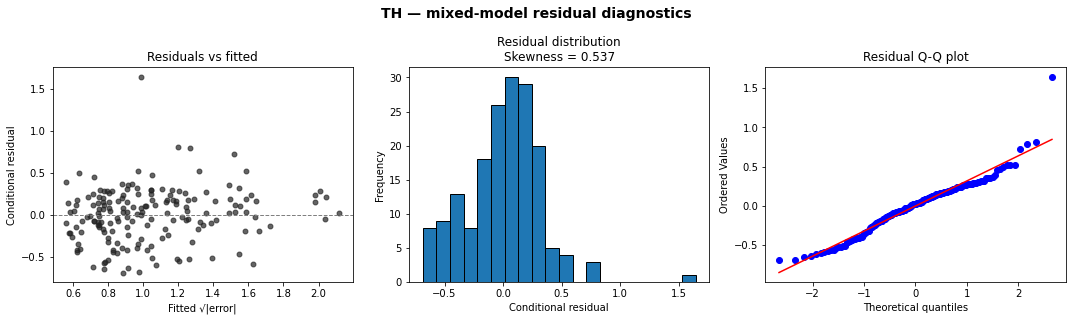

Saved: lmm_diagnostics_th.png

DBH — conditional residual diagnostics
Residual mean: -0.0
Residual SD: 0.069609
Residual skewness: -0.018
Residual range: (-0.178, 0.2093)


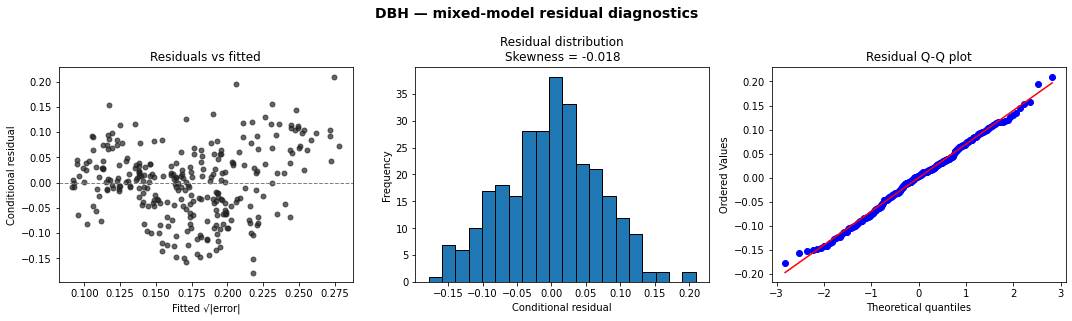

Saved: lmm_diagnostics_dbh.png


In [9]:
# Check the conditional residuals from each mixed-effects model
# MixedLM conditional fitted values include the estimated random intercept for each tree
# The corresponding residuals are used to assess:
# - residuals versus fitted values
# - residual distribution
# - Q-Q behaviour
# - unusually large residuals

from scipy.stats import skew, probplot


def model_diagnostics(
    result,
    data,
    attribute,
):
    """
    Calculate and plot conditional residual diagnostics for one mixed-effects model.
    """

    diagnostic_data = (
        data
        .copy()
        .reset_index(drop=True)
    )


    diagnostic_data[
        "Fitted"
    ] = np.asarray(
        result.fittedvalues
    )


    diagnostic_data[
        "Conditional_residual"
    ] = np.asarray(
        result.resid
    )


    diagnostic_data[
        "Absolute_conditional_residual"
    ] = (
        diagnostic_data[
            "Conditional_residual"
        ]
        .abs()
    )


    residuals = (
        diagnostic_data[
            "Conditional_residual"
        ]
        .to_numpy()
    )


    residual_skewness = skew(
        residuals,
        bias=False,
    )


    # Summarise the residual distribution numerically
    print(
        "\n" + "=" * 70
    )

    print(
        f"{attribute} — conditional residual diagnostics"
    )

    print(
        "=" * 70
    )

    print(
        "Residual mean:",
        round(
            residuals.mean(),
            6,
        )
    )

    print(
        "Residual SD:",
        round(
            residuals.std(
                ddof=1
            ),
            6,
        )
    )

    print(
        "Residual skewness:",
        round(
            residual_skewness,
            3,
        )
    )

    print(
        "Residual range:",
        (
            round(
                residuals.min(),
                4,
            ),
            round(
                residuals.max(),
                4,
            ),
        )
    )


    # Plot residuals against fitted values, their distribution and the corresponding normal Q-Q plot
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.5),
    )


    # Residuals versus fitted values
    axes[0].scatter(
        diagnostic_data["Fitted"],
        diagnostic_data["Conditional_residual"],
        s=24,
        alpha=0.70,
        color="#222222",
    )

    axes[0].axhline(
        0,
        linestyle="--",
        linewidth=1,
        color="0.5",
    )

    axes[0].set_xlabel(
        "Fitted √|error|"
    )

    axes[0].set_ylabel(
        "Conditional residual"
    )

    axes[0].set_title(
        "Residuals vs fitted"
    )


    # Residual distribution
    axes[1].hist(
        residuals,
        bins=20,
        edgecolor="black",
    )

    axes[1].set_xlabel(
        "Conditional residual"
    )

    axes[1].set_ylabel(
        "Frequency"
    )

    axes[1].set_title(
        "Residual distribution\n"
        f"Skewness = {residual_skewness:.3f}"
    )


    # Normal Q-Q plot
    probplot(
        residuals,
        dist="norm",
        plot=axes[2],
    )

    axes[2].set_title(
        "Residual Q-Q plot"
    )


    fig.suptitle(
        (
            f"{attribute} — mixed-model "
            "residual diagnostics"
        ),
        fontsize=14,
        fontweight="bold",
    )


    plt.tight_layout()


    # Save the diagnostic figure for this attribute
    figure_path = (
        FIGURES_DIR
        / f"lmm_diagnostics_{attribute.lower()}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    print(
        f"Saved: {figure_path.name}"
    )


    return diagnostic_data


# Run the same residual checks for the TH and DBH models
th_diagnostics = model_diagnostics(
    th_result,
    th_data,
    "TH",
)


dbh_diagnostics = model_diagnostics(
    dbh_result,
    dbh_data,
    "DBH",
)

In [10]:
# Identify the observations with the largest conditional residuals

columns_to_show = [
    "Terrain",
    "Scanner",
    "Workflow",
    "GT_ID",
    "GT_value",
    "Predicted_value",
    "Error",
    "Absolute_error",
    "Conditional_residual",
    "Absolute_conditional_residual",
]


print(
    "TH — 10 largest absolute conditional residuals\n"
)

print(
    th_diagnostics
    .sort_values(
        "Absolute_conditional_residual",
        ascending=False,
    )
    [columns_to_show]
    .head(10)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


print(
    "\nDBH — 10 largest absolute conditional residuals\n"
)

print(
    dbh_diagnostics
    .sort_values(
        "Absolute_conditional_residual",
        ascending=False,
    )
    [columns_to_show]
    .head(10)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

TH — 10 largest absolute conditional residuals

      Terrain        Scanner Workflow  GT_ID  GT_value  Predicted_value   Error  Absolute_error  Conditional_residual  Absolute_conditional_residual
  Challenging    Dual sensor      RCT      2   26.4000          19.4676 -6.9324          6.9324                1.6437                         1.6437
         Easy  Single sensor    3DFin     21   31.4000          27.3428 -4.0572          4.0572                0.8146                         0.8146
         Easy  Single sensor    3DFin     27   30.5000          26.2501 -4.2499          4.2499                0.7947                         0.7947
  Challenging    Dual sensor    3DFin     16   27.0000          21.9647 -5.0353          5.0353                0.7249                         0.7249
  Challenging    Dual sensor    3DFin      2   26.4000          26.4383  0.0383          0.0383               -0.6871                         0.6871
  Challenging  Single sensor    3DFin     14   24.7000    

In [11]:
# Test whether the TH mixed-model results are sensitive to the extreme observation identified in the residual diagnostics:
# - Challenging × Dual sensor × RCT × GT2
# Only this single observation is removed
# The remaining five TH observations for GT2 stay in the sensitivity dataset


# Identify the extreme observation
th_extreme_mask = (
    (
        th_data["Terrain"].astype(str)
        == "Challenging"
    )
    &
    (
        th_data["Scanner"].astype(str)
        == "Dual sensor"
    )
    &
    (
        th_data["Workflow"].astype(str)
        == "RCT"
    )
    &
    (
        th_data["GT_ID"]
        == 2
    )
)


require(
    th_extreme_mask.sum() == 1,
    (
        "Expected exactly one extreme TH observation "
        f"but found {th_extreme_mask.sum()}."
    ),
)


excluded_th_observation = (
    th_data.loc[
        th_extreme_mask,
        [
            "Terrain",
            "Scanner",
            "Workflow",
            "GT_ID",
            "GT_value",
            "Predicted_value",
            "Error",
            "Absolute_error",
            "SqrtAbsError",
        ],
    ]
)


print(
    "Observation excluded from TH sensitivity model:\n"
)

print(
    excluded_th_observation
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


# Create the sensitivity dataset by removing only the identified extreme observation
th_sensitivity_data = (
    th_data.loc[
        ~th_extreme_mask
    ]
    .copy()
)


print(
    "\nPrimary observations:",
    len(th_data)
)

print(
    "Sensitivity observations:",
    len(th_sensitivity_data)
)

print(
    "Primary trees:",
    th_data["Terrain_GT"].nunique()
)

print(
    "Sensitivity trees:",
    th_sensitivity_data["Terrain_GT"].nunique()
)


require(
    len(th_sensitivity_data) == 173,
    "Expected 173 TH observations after exclusion.",
)

require(
    th_sensitivity_data["Terrain_GT"].nunique() == 29,
    "Expected all 29 physical trees to remain represented.",
)


# Refit the same TH mixed-effects model to the reduced dataset
th_sensitivity_model = smf.mixedlm(
    (
        "SqrtAbsError ~ "
        "C(Scanner) * C(Workflow) + "
        "C(Terrain)"
    ),
    data=th_sensitivity_data,
    groups=th_sensitivity_data["Terrain_GT"],
)


th_sensitivity_result = (
    th_sensitivity_model.fit(
        reml=True,
        method="lbfgs",
        maxiter=5000,
        disp=False,
    )
)


# Report the main fit information and residual behaviour after removing the extreme observation
print(
    "\nTH SENSITIVITY MODEL"
)

print(
    "=" * 70
)

print(
    "Converged:",
    th_sensitivity_result.converged
)

print(
    "Random-intercept variance:",
    float(
        th_sensitivity_result
        .cov_re.iloc[0, 0]
    )
)

print(
    "Residual variance:",
    th_sensitivity_result.scale
)

print(
    "Conditional residual skewness:",
    round(
        stats.skew(
            th_sensitivity_result.resid,
            bias=False,
        ),
        3,
    )
)

print(
    "\nModel summary:\n"
)

print(
    th_sensitivity_result.summary()
)

Observation excluded from TH sensitivity model:

     Terrain      Scanner Workflow  GT_ID  GT_value  Predicted_value   Error  Absolute_error  SqrtAbsError
 Challenging  Dual sensor      RCT      2   26.4000          19.4676 -6.9324          6.9324        2.6329

Primary observations: 174
Sensitivity observations: 173
Primary trees: 29
Sensitivity trees: 29

TH SENSITIVITY MODEL
Converged: True
Random-intercept variance: 0.1484250191512842
Residual variance: 0.10296152808487806
Conditional residual skewness: -0.201

Model summary:

                         Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          SqrtAbsError
No. Observations:            173              Method:                      REML        
No. Groups:                  29               Scale:                       0.1030      
Min. group size:             5                Log-Likelihood:              -89.3681    
Max. group size:             6                C

In [12]:
# Compare the primary TH model with the sensitivity model
# The sensitivity analysis does not replace the primary model
# It checks whether removing the extreme observation changes the overall inferential conclusions


def make_omnibus_table(
    result,
    model_name,
):
    """
    Run the same four omnibus tests for one fitted model.
    """

    rows = [

        marginal_omnibus_test(
            result,
            "Scanner",
            scanner_order,
        ),

        marginal_omnibus_test(
            result,
            "Workflow",
            workflow_order,
        ),

        marginal_omnibus_test(
            result,
            "Terrain",
            terrain_order,
        ),

        interaction_wald_test(
            result
        ),
    ]


    output = pd.DataFrame(
        rows
    )


    output.insert(
        0,
        "Model",
        model_name,
    )


    return output


# Compare the omnibus tests from the primary and sensitivity models
th_primary_tests = make_omnibus_table(
    th_result,
    "Primary",
)


th_sensitivity_tests = make_omnibus_table(
    th_sensitivity_result,
    "Sensitivity",
)


th_sensitivity_omnibus = pd.concat(
    [
        th_primary_tests,
        th_sensitivity_tests,
    ],
    ignore_index=True,
)


print(
    "TH — primary vs sensitivity omnibus tests\n"
)


print(
    th_sensitivity_omnibus
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


# Compare the treatment-coded fixed-effect coefficients as an additional stability check
# These coefficients are not used as the overall Scanner or Workflow significance tests
# because they depend on the model's reference categories
th_fixed_effect_comparison = pd.DataFrame(
    {
        "Primary_estimate":
            th_result.fe_params,

        "Sensitivity_estimate":
            th_sensitivity_result.fe_params,

        "Primary_SE":
            th_result.bse_fe,

        "Sensitivity_SE":
            th_sensitivity_result.bse_fe,

        "Primary_p":
            th_result.pvalues[
                th_result.fe_params.index
            ],

        "Sensitivity_p":
            th_sensitivity_result.pvalues[
                th_sensitivity_result.fe_params.index
            ],
    }
)


th_fixed_effect_comparison[
    "Estimate_change"
] = (
    th_fixed_effect_comparison[
        "Sensitivity_estimate"
    ]
    -
    th_fixed_effect_comparison[
        "Primary_estimate"
    ]
)


print(
    "\nTH — fixed-effect stability check\n"
)


print(
    th_fixed_effect_comparison
    .round(4)
    .to_string()
)


# Compare the main fit and residual diagnostics before and after removing the extreme observation
th_diagnostic_comparison = pd.DataFrame(
    {
        "Model": [
            "Primary",
            "Sensitivity",
        ],

        "Observations": [
            len(th_data),
            len(th_sensitivity_data),
        ],

        "Trees": [
            th_data["Terrain_GT"].nunique(),
            th_sensitivity_data["Terrain_GT"].nunique(),
        ],

        "Random_intercept_variance": [
            float(
                th_result.cov_re.iloc[0, 0]
            ),
            float(
                th_sensitivity_result.cov_re.iloc[0, 0]
            ),
        ],

        "Residual_variance": [
            th_result.scale,
            th_sensitivity_result.scale,
        ],

        "Residual_skewness": [
            stats.skew(
                th_result.resid,
                bias=False,
            ),
            stats.skew(
                th_sensitivity_result.resid,
                bias=False,
            ),
        ],
    }
)


print(
    "\nTH — diagnostic comparison\n"
)


print(
    th_diagnostic_comparison
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

TH — primary vs sensitivity omnibus tests

       Model              Effect  Chi_square  df  p_value
     Primary             Scanner    0.924919   2 0.629733
     Primary            Workflow    0.380095   1 0.537553
     Primary             Terrain    2.431893   2 0.296429
     Primary  Scanner × Workflow    1.684483   2 0.430744
 Sensitivity             Scanner    0.155823   2 0.925046
 Sensitivity            Workflow    0.043626   1 0.834550
 Sensitivity             Terrain    1.874558   2 0.391692
 Sensitivity  Scanner × Workflow    1.101658   2 0.576472

TH — fixed-effect stability check

                                              Primary_estimate  Sensitivity_estimate  Primary_SE  Sensitivity_SE  Primary_p  Sensitivity_p  Estimate_change
Intercept                                               1.1215                1.1330      0.2054          0.2106     0.0000         0.0000           0.0116
C(Scanner)[T.Dual sensor]                              -0.0299               -0.0299   

In [13]:
# Run a non-parametric robustness check for the Scanner effect
# The mixed-effects models found no overall Scanner effect
# As a complementary check, compare the three scanners using paired Friedman tests within each: Workflow × Terrain × Attribute
# The same physical GT trees are represented for all three scanners within each test, so the observations are paired
# This gives: 2 workflows × 3 terrains × 2 attributes = 12 tests
# Holm correction is applied across all 12 p-values
# Kendall's W is reported as an effect-size measure

from scipy.stats import friedmanchisquare
from statsmodels.stats.multitest import multipletests


friedman_rows = []


for attribute in attribute_order:

    for workflow in workflow_order:

        for terrain in terrain_order:

            subset = (
                model_data[
                    (
                        model_data["Attribute"]
                        == attribute
                    )
                    &
                    (
                        model_data["Workflow"]
                        == workflow
                    )
                    &
                    (
                        model_data["Terrain"]
                        == terrain
                    )
                ]
                .copy()
            )


            # Put the three scanner measurements for each physical tree on the same row
            wide = (
                subset
                .set_index(
                    [
                        "GT_ID",
                        "Scanner",
                    ]
                )[
                    "Absolute_error"
                ]
                .unstack(
                    "Scanner"
                )
            )


            # Keep the scanner columns in the intended order
            wide = wide[
                scanner_order
            ]


            # The strict common-tree sample should contain a complete set of three scanner measurements per tree
            require(
                not wide.isna().any().any(),
                (
                    "Incomplete scanner pairing found for "
                    f"{workflow}, {terrain}, {attribute}."
                ),
            )


            n_trees = len(
                wide
            )


            require(
                n_trees >= 3,
                (
                    "Too few paired trees for Friedman test: "
                    f"{workflow}, {terrain}, {attribute}."
                ),
            )


            # Test for differences in absolute error among the three scanners within this subset
            statistic, raw_p = friedmanchisquare(
                wide["Single sensor"],
                wide["Dual sensor"],
                wide["Hovermap"],
            )


            # Calculate Kendall's W from the Friedman statistic as a measure of effect size
            # W = chi-square / [n × (k - 1)]
            # where k = 3 scanners
            
            k_scanners = 3

            kendalls_w = (
                statistic
                /
                (
                    n_trees
                    * (k_scanners - 1)
                )
            )


            # Store the inferential results together with descriptive absolute-error statistics
            row = {
                "Workflow":
                    workflow,

                "Terrain":
                    terrain,

                "Attribute":
                    attribute,

                "n":
                    n_trees,

                "Friedman_chi2":
                    statistic,

                "df":
                    k_scanners - 1,

                "Raw_p":
                    raw_p,

                "Kendalls_W":
                    kendalls_w,
            }


            for scanner in scanner_order:

                scanner_values = (
                    wide[scanner]
                    .to_numpy(
                        dtype=float
                    )
                )

                short_name = {
                    "Single sensor": "Single",
                    "Dual sensor": "Dual",
                    "Hovermap": "Hovermap",
                }[scanner]


                row[
                    f"{short_name}_mean_abs_error"
                ] = np.mean(
                    scanner_values
                )


                row[
                    f"{short_name}_median_abs_error"
                ] = np.median(
                    scanner_values
                )


            friedman_rows.append(
                row
            )


# Combine the 12 stratified scanner tests into one results table
friedman_results = pd.DataFrame(
    friedman_rows
)


require(
    len(friedman_results) == 12,
    (
        "Expected exactly 12 Friedman tests, "
        f"but found {len(friedman_results)}."
    ),
)


# Apply a Holm correction across all 12 scanner comparisons
reject, holm_p, _, _ = multipletests(
    friedman_results[
        "Raw_p"
    ],
    alpha=0.05,
    method="holm",
)


friedman_results[
    "Holm_p"
] = holm_p


friedman_results[
    "Significant_after_Holm"
] = reject


# Display the main inferential results
columns_to_print = [
    "Workflow",
    "Terrain",
    "Attribute",
    "n",
    "Friedman_chi2",
    "df",
    "Raw_p",
    "Kendalls_W",
    "Holm_p",
    "Significant_after_Holm",
]


print(
    "Scanner comparison — Friedman tests\n"
)


print(
    friedman_results[
        columns_to_print
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


print(
    "\nNumber significant before Holm correction:",
    (
        friedman_results["Raw_p"]
        < 0.05
    ).sum(),
)


print(
    "Number significant after Holm correction:",
    friedman_results[
        "Significant_after_Holm"
    ].sum(),
)


# Save the full Friedman-test results, including the descriptive statistics for each scanner
friedman_path = (
    TABLES_DIR
    / "scanner_friedman_tests.csv"
)


friedman_results.to_csv(
    friedman_path,
    index=False,
)


print(
    f"\nSaved: {friedman_path.name}"
)

Scanner comparison — Friedman tests

Workflow       Terrain Attribute   n  Friedman_chi2  df    Raw_p  Kendalls_W   Holm_p  Significant_after_Holm
   3DFin          Easy        TH   4       1.500000   2 0.472367    0.187500 1.000000                   False
   3DFin  Intermediate        TH  12       2.166667   2 0.338465    0.090278 1.000000                   False
   3DFin   Challenging        TH  13       2.923077   2 0.231879    0.112426 1.000000                   False
     RCT          Easy        TH   4       2.000000   2 0.367879    0.250000 1.000000                   False
     RCT  Intermediate        TH  12       2.166667   2 0.338465    0.090278 1.000000                   False
     RCT   Challenging        TH  13       0.117647   2 0.942873    0.004525 1.000000                   False
   3DFin          Easy       DBH   9       1.555556   2 0.459426    0.086420 1.000000                   False
   3DFin  Intermediate       DBH  21       3.523810   2 0.171717    0.083900 1.0000

In [14]:
# Save the main outputs from the mixed-effects and robustness analysis
# Combine the TH and DBH omnibus Wald tests into one table

lmm_omnibus_tests = pd.concat(
    [
        th_omnibus_tests.assign(
            Attribute="TH"
        ),
        dbh_omnibus_tests.assign(
            Attribute="DBH"
        ),
    ],
    ignore_index=True,
)


lmm_omnibus_tests = lmm_omnibus_tests[
    [
        "Attribute",
        "Effect",
        "Chi_square",
        "df",
        "p_value",
    ]
]


omnibus_path = (
    TABLES_DIR
    / "lmm_omnibus_tests.csv"
)


lmm_omnibus_tests.to_csv(
    omnibus_path,
    index=False,
)


print(
    f"Saved: {omnibus_path.name}"
)


# Save the DBH workflow and terrain post-hoc comparisons
dbh_workflow_path = (
    TABLES_DIR
    / "dbh_workflow_contrast.csv"
)


dbh_terrain_path = (
    TABLES_DIR
    / "dbh_terrain_pairwise_contrasts.csv"
)


dbh_workflow_contrast.to_csv(
    dbh_workflow_path,
    index=False,
)


dbh_terrain_contrasts.to_csv(
    dbh_terrain_path,
    index=False,
)


print(
    f"Saved: {dbh_workflow_path.name}"
)

print(
    f"Saved: {dbh_terrain_path.name}"
)


# Combine all TH and DBH estimated marginal means into one table
lmm_emms = pd.concat(
    [
        th_emm_scanner.assign(
            Attribute="TH"
        ),
        th_emm_workflow.assign(
            Attribute="TH"
        ),
        th_emm_terrain.assign(
            Attribute="TH"
        ),
        dbh_emm_scanner.assign(
            Attribute="DBH"
        ),
        dbh_emm_workflow.assign(
            Attribute="DBH"
        ),
        dbh_emm_terrain.assign(
            Attribute="DBH"
        ),
    ],
    ignore_index=True,
)


lmm_emms = lmm_emms[
    [
        "Attribute",
        "Factor",
        "Level",
        "EMM_sqrt_abs_error",
        "SE",
        "CI_lower_sqrt",
        "CI_upper_sqrt",
        "Back_transformed",
        "Back_CI_lower",
        "Back_CI_upper",
        "Unit",
    ]
]


emm_path = (
    TABLES_DIR
    / "lmm_estimated_marginal_means.csv"
)


lmm_emms.to_csv(
    emm_path,
    index=False,
)


print(
    f"Saved: {emm_path.name}"
)


# Save the TH sensitivity-analysis results
th_sensitivity_omnibus_path = (
    TABLES_DIR
    / "th_gt2_sensitivity_omnibus_tests.csv"
)


th_sensitivity_fixed_path = (
    TABLES_DIR
    / "th_gt2_sensitivity_fixed_effects.csv"
)


th_sensitivity_diagnostic_path = (
    TABLES_DIR
    / "th_gt2_sensitivity_diagnostics.csv"
)


th_sensitivity_omnibus.to_csv(
    th_sensitivity_omnibus_path,
    index=False,
)


th_fixed_effect_comparison.to_csv(
    th_sensitivity_fixed_path
)


th_diagnostic_comparison.to_csv(
    th_sensitivity_diagnostic_path,
    index=False,
)


print(
    f"Saved: {th_sensitivity_omnibus_path.name}"
)

print(
    f"Saved: {th_sensitivity_fixed_path.name}"
)

print(
    f"Saved: {th_sensitivity_diagnostic_path.name}"
)


# Save the extreme TH observation identified in the residual diagnostics so the sensitivity analysis can be traced directly
extreme_th_path = (
    TABLES_DIR
    / "th_extreme_observation_gt2.csv"
)


excluded_th_observation.to_csv(
    extreme_th_path,
    index=False,
)


print(
    f"Saved: {extreme_th_path.name}"
)


# Check that all expected Notebook 04 tables and figures exist
expected_outputs = [

    TABLES_DIR
    / "lmm_omnibus_tests.csv",

    TABLES_DIR
    / "dbh_workflow_contrast.csv",

    TABLES_DIR
    / "dbh_terrain_pairwise_contrasts.csv",

    TABLES_DIR
    / "lmm_estimated_marginal_means.csv",

    TABLES_DIR
    / "th_gt2_sensitivity_omnibus_tests.csv",

    TABLES_DIR
    / "th_gt2_sensitivity_fixed_effects.csv",

    TABLES_DIR
    / "th_gt2_sensitivity_diagnostics.csv",

    TABLES_DIR
    / "th_extreme_observation_gt2.csv",

    TABLES_DIR
    / "scanner_friedman_tests.csv",

    FIGURES_DIR
    / "lmm_diagnostics_th.png",

    FIGURES_DIR
    / "lmm_diagnostics_dbh.png",
]


missing_outputs = []


print(
    "\nNotebook 04 output audit:\n"
)


for path in expected_outputs:

    if path.exists():

        print(
            f"OK  {path.name}"
        )

    else:

        print(
            f"MISSING  {path.name}"
        )

        missing_outputs.append(
            path
        )


# Run the main scientific checks expected from the final analysis
require(
    th_result.converged,
    "Primary TH model did not converge.",
)


require(
    dbh_result.converged,
    "DBH model did not converge.",
)


require(
    th_sensitivity_result.converged,
    "TH sensitivity model did not converge.",
)


require(
    len(lmm_omnibus_tests) == 8,
    "Expected eight primary omnibus tests.",
)


require(
    len(friedman_results) == 12,
    "Expected twelve Friedman scanner tests.",
)


require(
    (
        friedman_results[
            "Significant_after_Holm"
        ]
        .sum()
        == 0
    ),
    (
        "Unexpected Holm-significant "
        "scanner comparison found."
    ),
)


require(
    (
        th_sensitivity_tests[
            "p_value"
        ]
        > 0.05
    ).all(),
    (
        "A TH sensitivity-model omnibus effect "
        "became significant unexpectedly."
    ),
)


if missing_outputs:

    print(
        "\nNotebook 04 audit finished, "
        "but some expected files are missing."
    )

else:

    print(
        "\nNotebook 04 audit passed."
    )


print(
    "\nMixed-effects and scanner robustness "
    "analysis complete."
)

Saved: lmm_omnibus_tests.csv
Saved: dbh_workflow_contrast.csv
Saved: dbh_terrain_pairwise_contrasts.csv
Saved: lmm_estimated_marginal_means.csv
Saved: th_gt2_sensitivity_omnibus_tests.csv
Saved: th_gt2_sensitivity_fixed_effects.csv
Saved: th_gt2_sensitivity_diagnostics.csv
Saved: th_extreme_observation_gt2.csv

Notebook 04 output audit:

OK  lmm_omnibus_tests.csv
OK  dbh_workflow_contrast.csv
OK  dbh_terrain_pairwise_contrasts.csv
OK  lmm_estimated_marginal_means.csv
OK  th_gt2_sensitivity_omnibus_tests.csv
OK  th_gt2_sensitivity_fixed_effects.csv
OK  th_gt2_sensitivity_diagnostics.csv
OK  th_extreme_observation_gt2.csv
OK  scanner_friedman_tests.csv
OK  lmm_diagnostics_th.png
OK  lmm_diagnostics_dbh.png

Notebook 04 audit passed.

Mixed-effects and scanner robustness analysis complete.
